In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
    transforms.Resize((224,224)),    
    transforms.ToTensor() 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_0.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.36301109209060667, 0.8783142857142857)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.44985489149093627, 0.8439)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=2*p*r/(p+r)
each_accu

airplane      0.888320
automobile    0.940453
bird          0.854250
cat           0.779700
deer          0.847319
dog           0.805914
frog          0.916387
horse         0.882196
ship          0.933389
truck         0.937735
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[3, 5, 4, 2]

In [17]:
# targetF=[2,4]

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(13948, 21052)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(4046, 5954)

In [20]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [21]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i in idx:
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
        
            flat_data.extend(data.cpu().numpy()) 
                
    return flat_data,flat_true

In [22]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [23]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.16428349301644735,train_accu=0.9346285714285715
Epoch=0,valid_loss=0.20952757475972175,valid_accu=0.9113
0
Epoch=1,train_loss=0.12251652067005635,train_accu=0.9525714285714286
Epoch=1,valid_loss=0.18559748612642288,valid_accu=0.9231
0
Epoch=2,train_loss=0.09662278695106506,train_accu=0.9711428571428572
Epoch=2,valid_loss=0.16366491968631744,valid_accu=0.9344
0
Epoch=3,train_loss=0.061642110207570454,train_accu=0.9776
Epoch=3,valid_loss=0.1774783478692174,valid_accu=0.9347
0
Epoch=4,train_loss=0.055390291622493946,train_accu=0.9797428571428571
Epoch=4,valid_loss=0.19176206438019872,valid_accu=0.9347
Epoch=5,train_loss=0.06461786415108613,train_accu=0.9768285714285714
Epoch=5,valid_loss=0.2088279360830784,valid_accu=0.9294
Epoch=6,train_loss=0.04718085597239967,train_accu=0.9831142857142857
Epoch=6,valid_loss=0.20932043915316462,valid_accu=0.9336
Epoch=7,train_loss=0.02721921661896631,train_accu=0.9906
Epoch=7,valid_loss=0.18444555986523628,valid_accu=0.9419
0
Epoch=

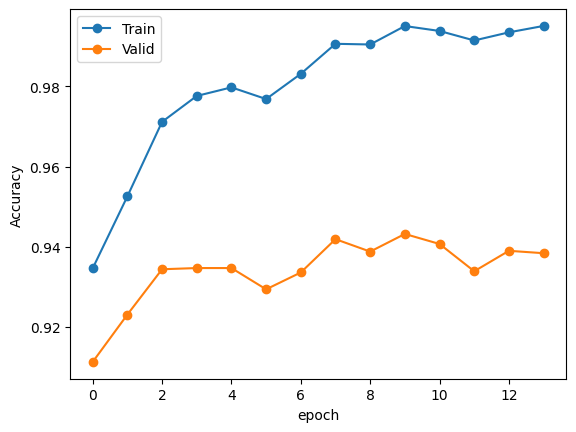

In [24]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.21837161888805334,train_accu=0.9239502185065552
Epoch=0,valid_loss=0.2840434765646023,valid_accu=0.9000671817265704
0
Epoch=1,train_loss=0.10473321726145415,train_accu=0.9636614098422953
Epoch=1,valid_loss=0.19920444998578574,valid_accu=0.9302989586832382
0
Epoch=2,train_loss=0.05973281257180842,train_accu=0.980524415732472
Epoch=2,valid_loss=0.1842727970520266,valid_accu=0.9371850856567013
0
Epoch=3,train_loss=0.045719894760507904,train_accu=0.9841345240357211
Epoch=3,valid_loss=0.21149787160126524,valid_accu=0.9326503191132012
Epoch=4,train_loss=0.028542676338111604,train_accu=0.9914497434923047
Epoch=4,valid_loss=0.19178758648488664,valid_accu=0.9407121263016459
0
Epoch=5,train_loss=0.01790810310392057,train_accu=0.9947273418202546
Epoch=5,valid_loss=0.19261168970938652,valid_accu=0.9440712126301646
0
Epoch=6,train_loss=0.027595559293267524,train_accu=0.9908797263917918
Epoch=6,valid_loss=0.2389106040217951,valid_accu=0.9363453140745717
Epoch=7,train_loss=0.0294

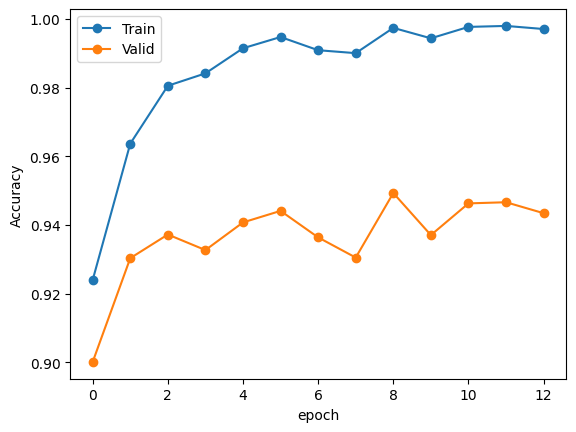

In [25]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [26]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=0.453437320014143,train_accu=0.8212646974476627
Epoch=0,valid_loss=0.5352655428356307,valid_accu=0.7889273356401384
0
Epoch=1,train_loss=0.2732265052239533,train_accu=0.9013478634929739
Epoch=1,valid_loss=0.4227564793615959,valid_accu=0.8376173999011369
0
Epoch=2,train_loss=0.1684746396620225,train_accu=0.9429308861485518
Epoch=2,valid_loss=0.38757358860450986,valid_accu=0.8593672763222936
0
Epoch=3,train_loss=0.10276593436821675,train_accu=0.967163751075423
Epoch=3,valid_loss=0.3847034844619121,valid_accu=0.8603559070687098
0
Epoch=4,train_loss=0.10394332715175814,train_accu=0.966518497275595
Epoch=4,valid_loss=0.43066039640185744,valid_accu=0.8487394957983193
Epoch=5,train_loss=0.08976881711893073,train_accu=0.9675939202753083
Epoch=5,valid_loss=0.47350457013095304,valid_accu=0.8504695996045477
Epoch=6,train_loss=0.04003285356015523,train_accu=0.9885288213363923
Epoch=6,valid_loss=0.4689882724401801,valid_accu=0.8623331685615423
0
Epoch=7,train_loss=0.0310482265284

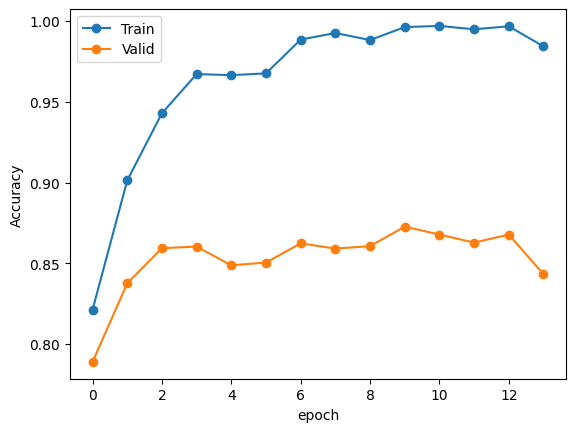

In [27]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [28]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.016858489026285575, 0.9946)

In [29]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.19770522650852798, 0.9432)

In [30]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.008157044453117063, 0.9973874216226487)

In [31]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.014567675910890636, 0.9962718669343275)

In [32]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.20751905052988012, 0.9492777964393685)

In [33]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.4768617301369091, 0.8727137913989125)

In [34]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.010711763562288668, 0.9969428571428571, 13948)

In [35]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.31649376643672583, 0.9183, 4046)

In [36]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)

            softmax=torch.softmax(out_growth, dim=1)

            out=model_decision(data)
            _, y_pred_tag = torch.max(out, dim = 1)


            for pred,d,t in zip(y_pred_tag,data,target):

                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    sum_F+=1
                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [37]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.1244352722311459, 0.9912857142857143, 14075, 20925)

In [38]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.490160729074478, 0.8706, 4198, 5802)

In [39]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [40]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.363011,0.878314,0.449855,0.843900
1,Model_Decision,0.016858,0.994600,0.016858,0.943200
2,Model_T,0.008157,0.997387,0.207519,0.949278
3,Model_F,0.014568,0.996272,0.476862,0.872714
4,Total_Model,0.124435,0.991286,1.490161,0.870600
5,Total_Model_without_decision,0.010712,0.996943,0.316494,0.918300


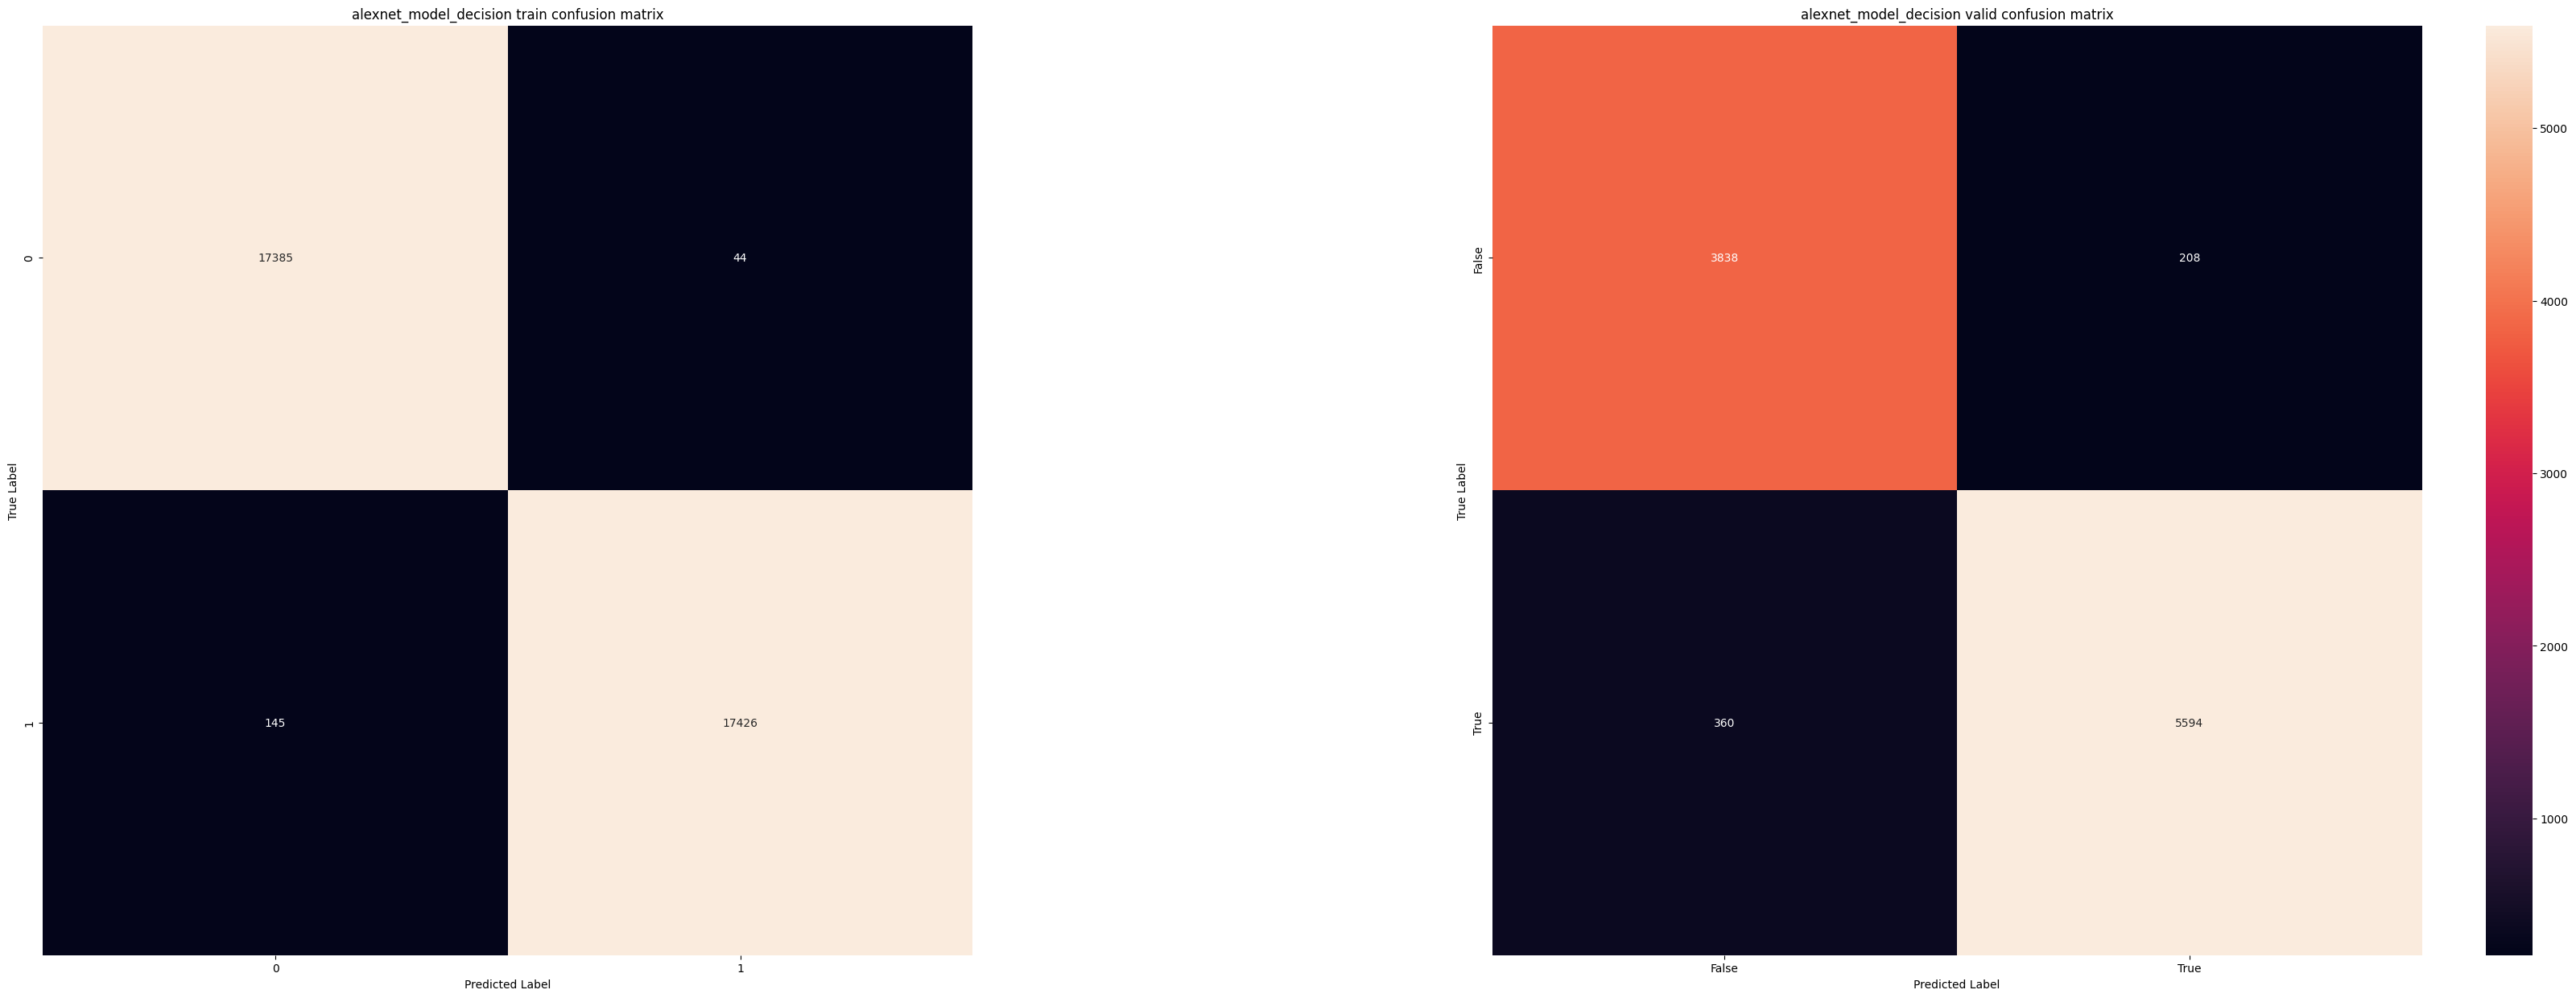

In [41]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

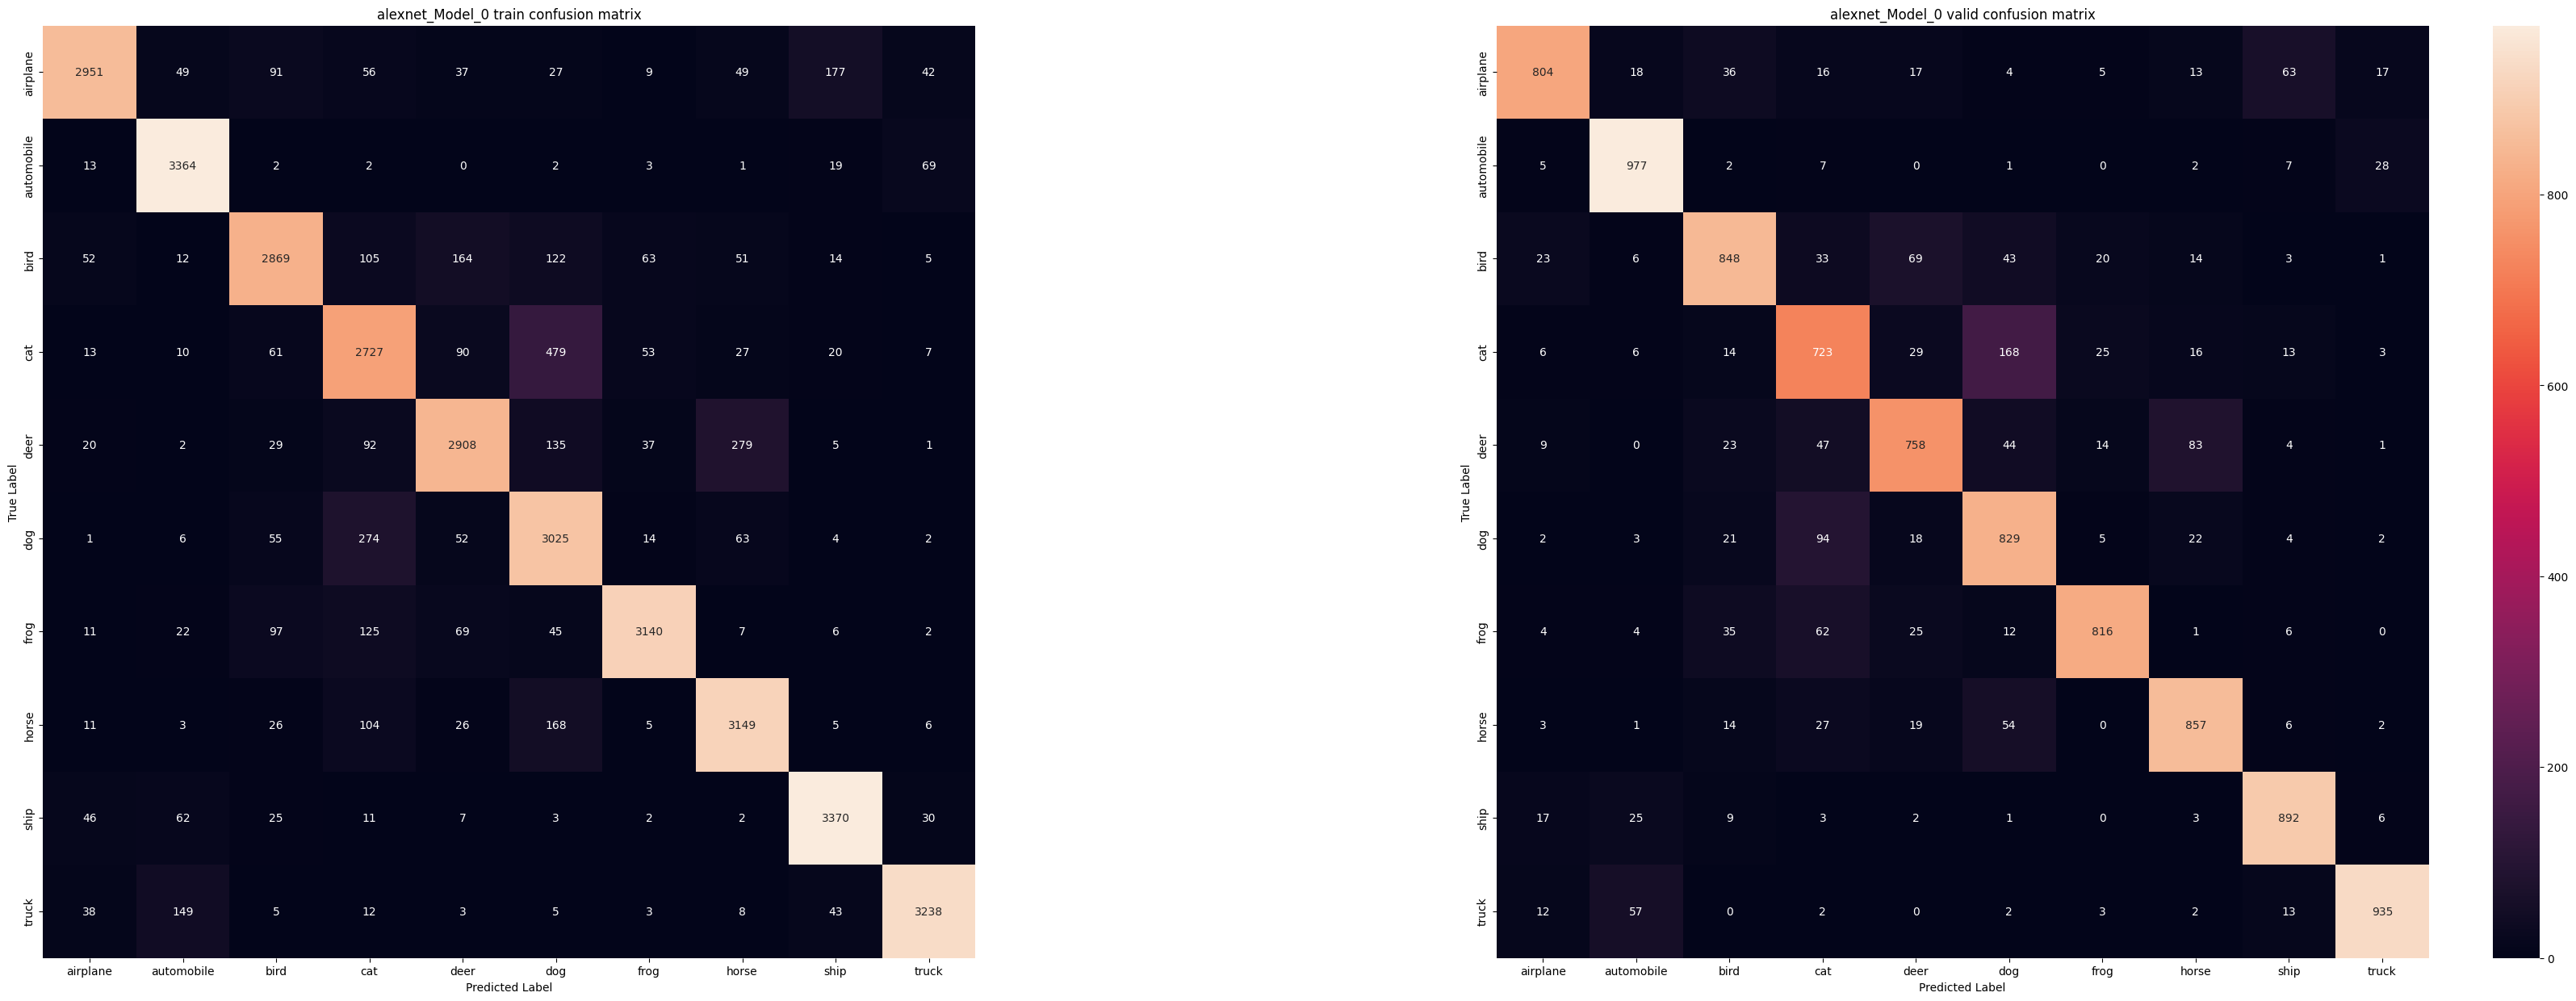

In [42]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

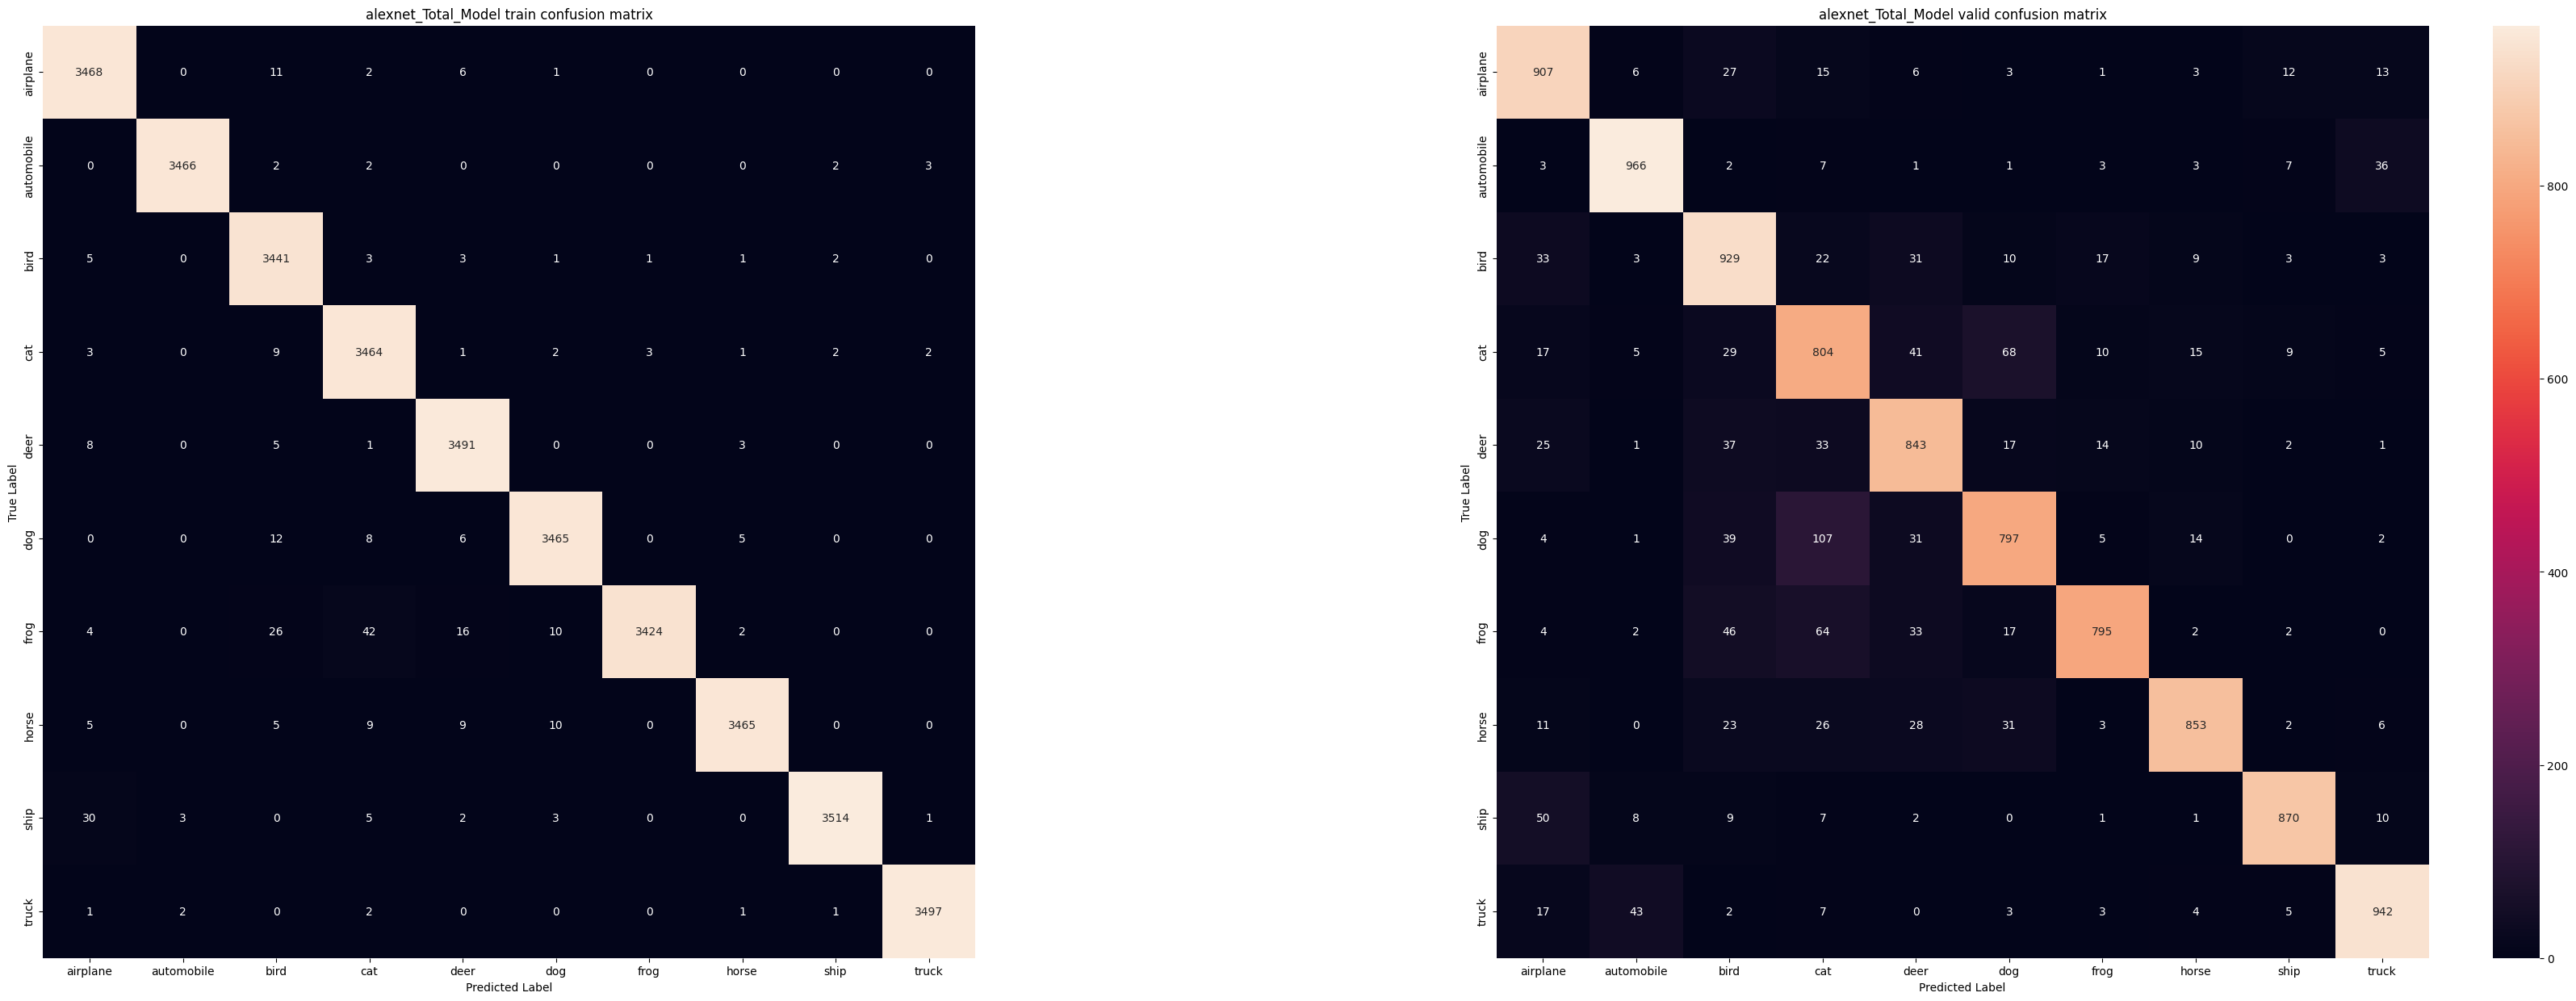

In [43]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

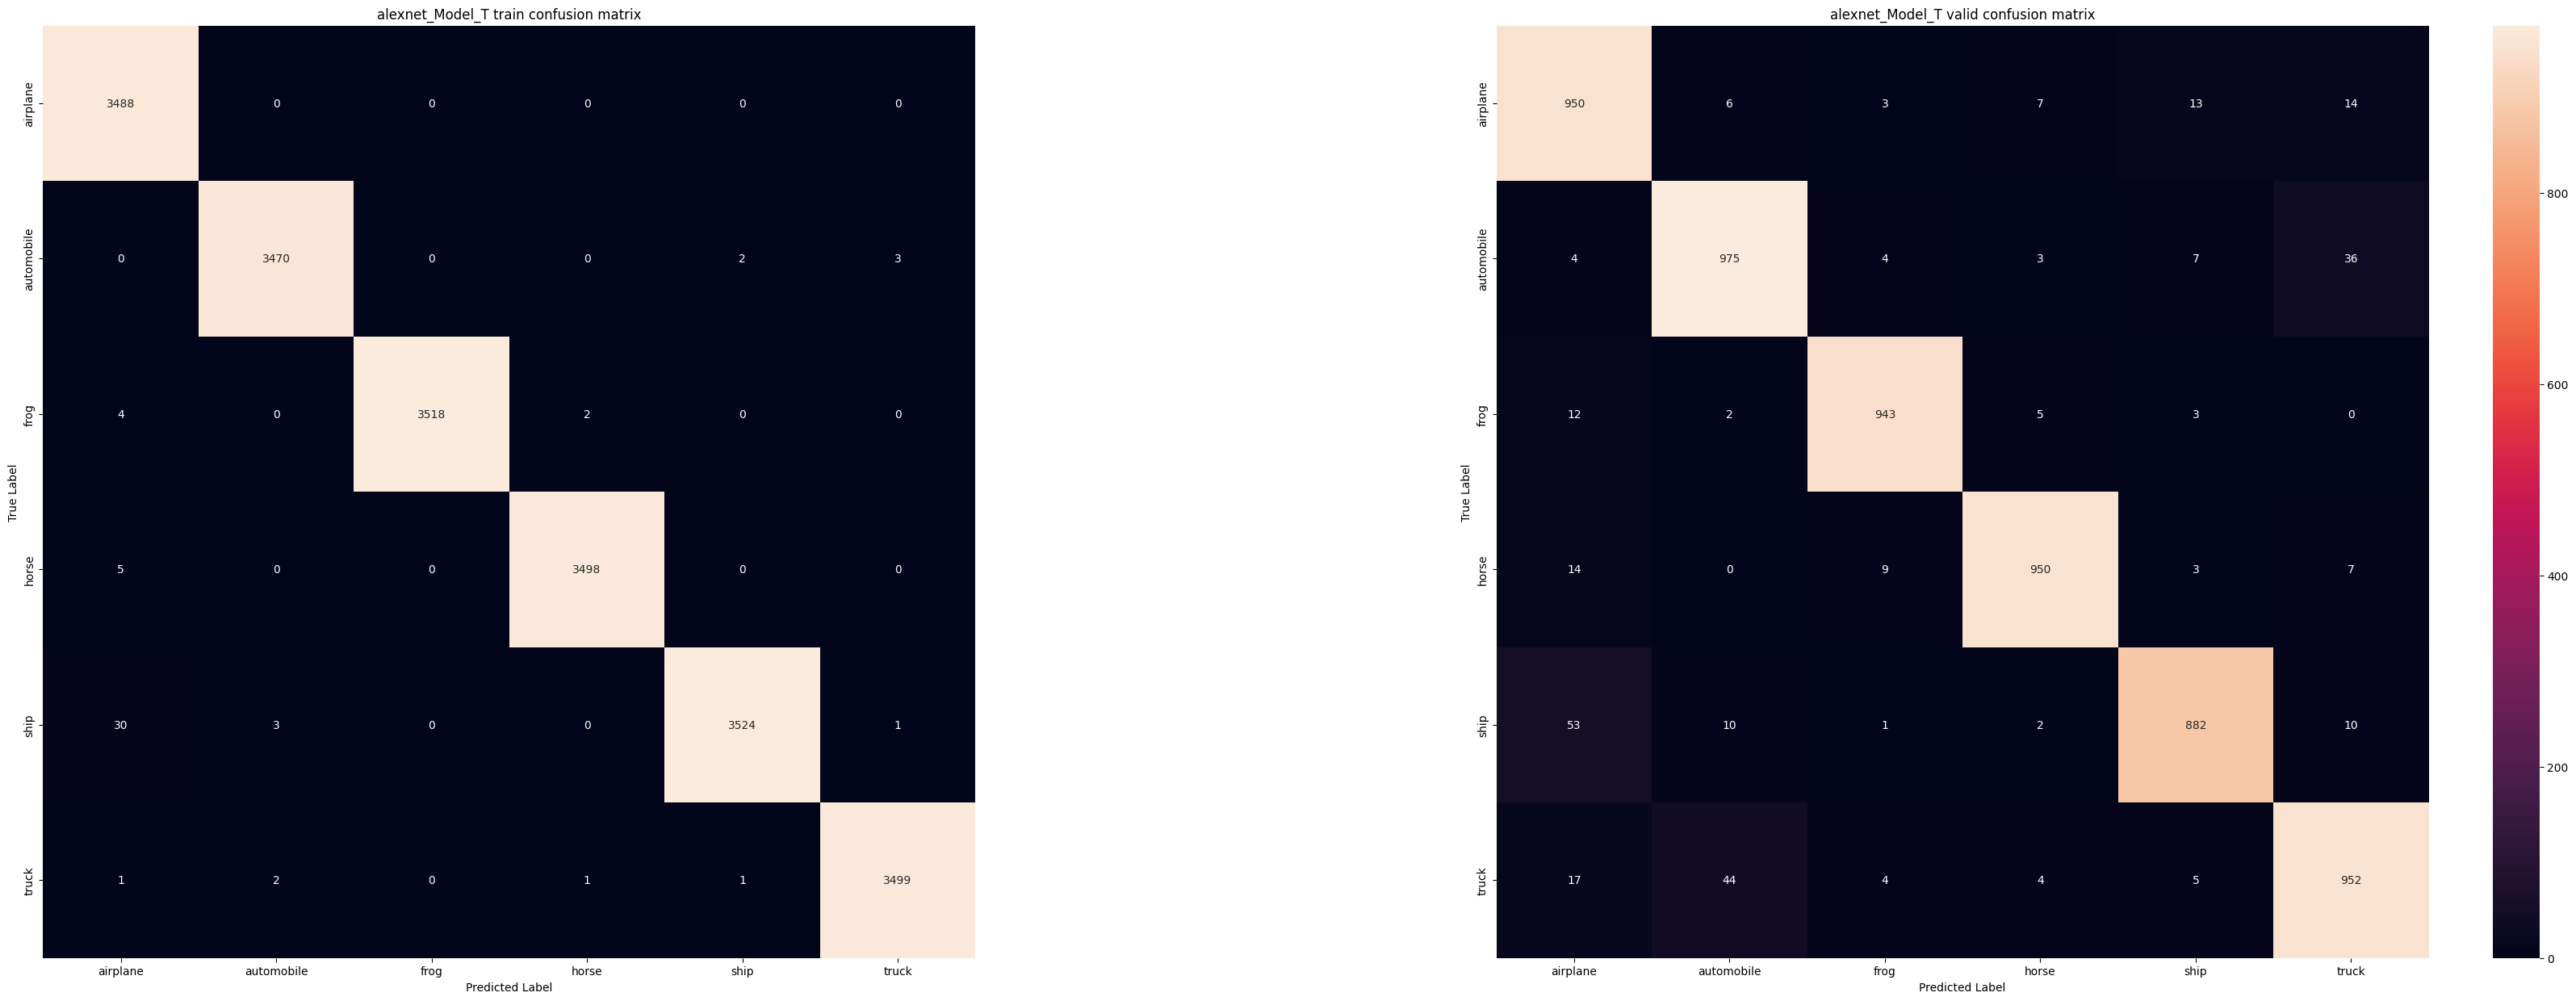

In [44]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

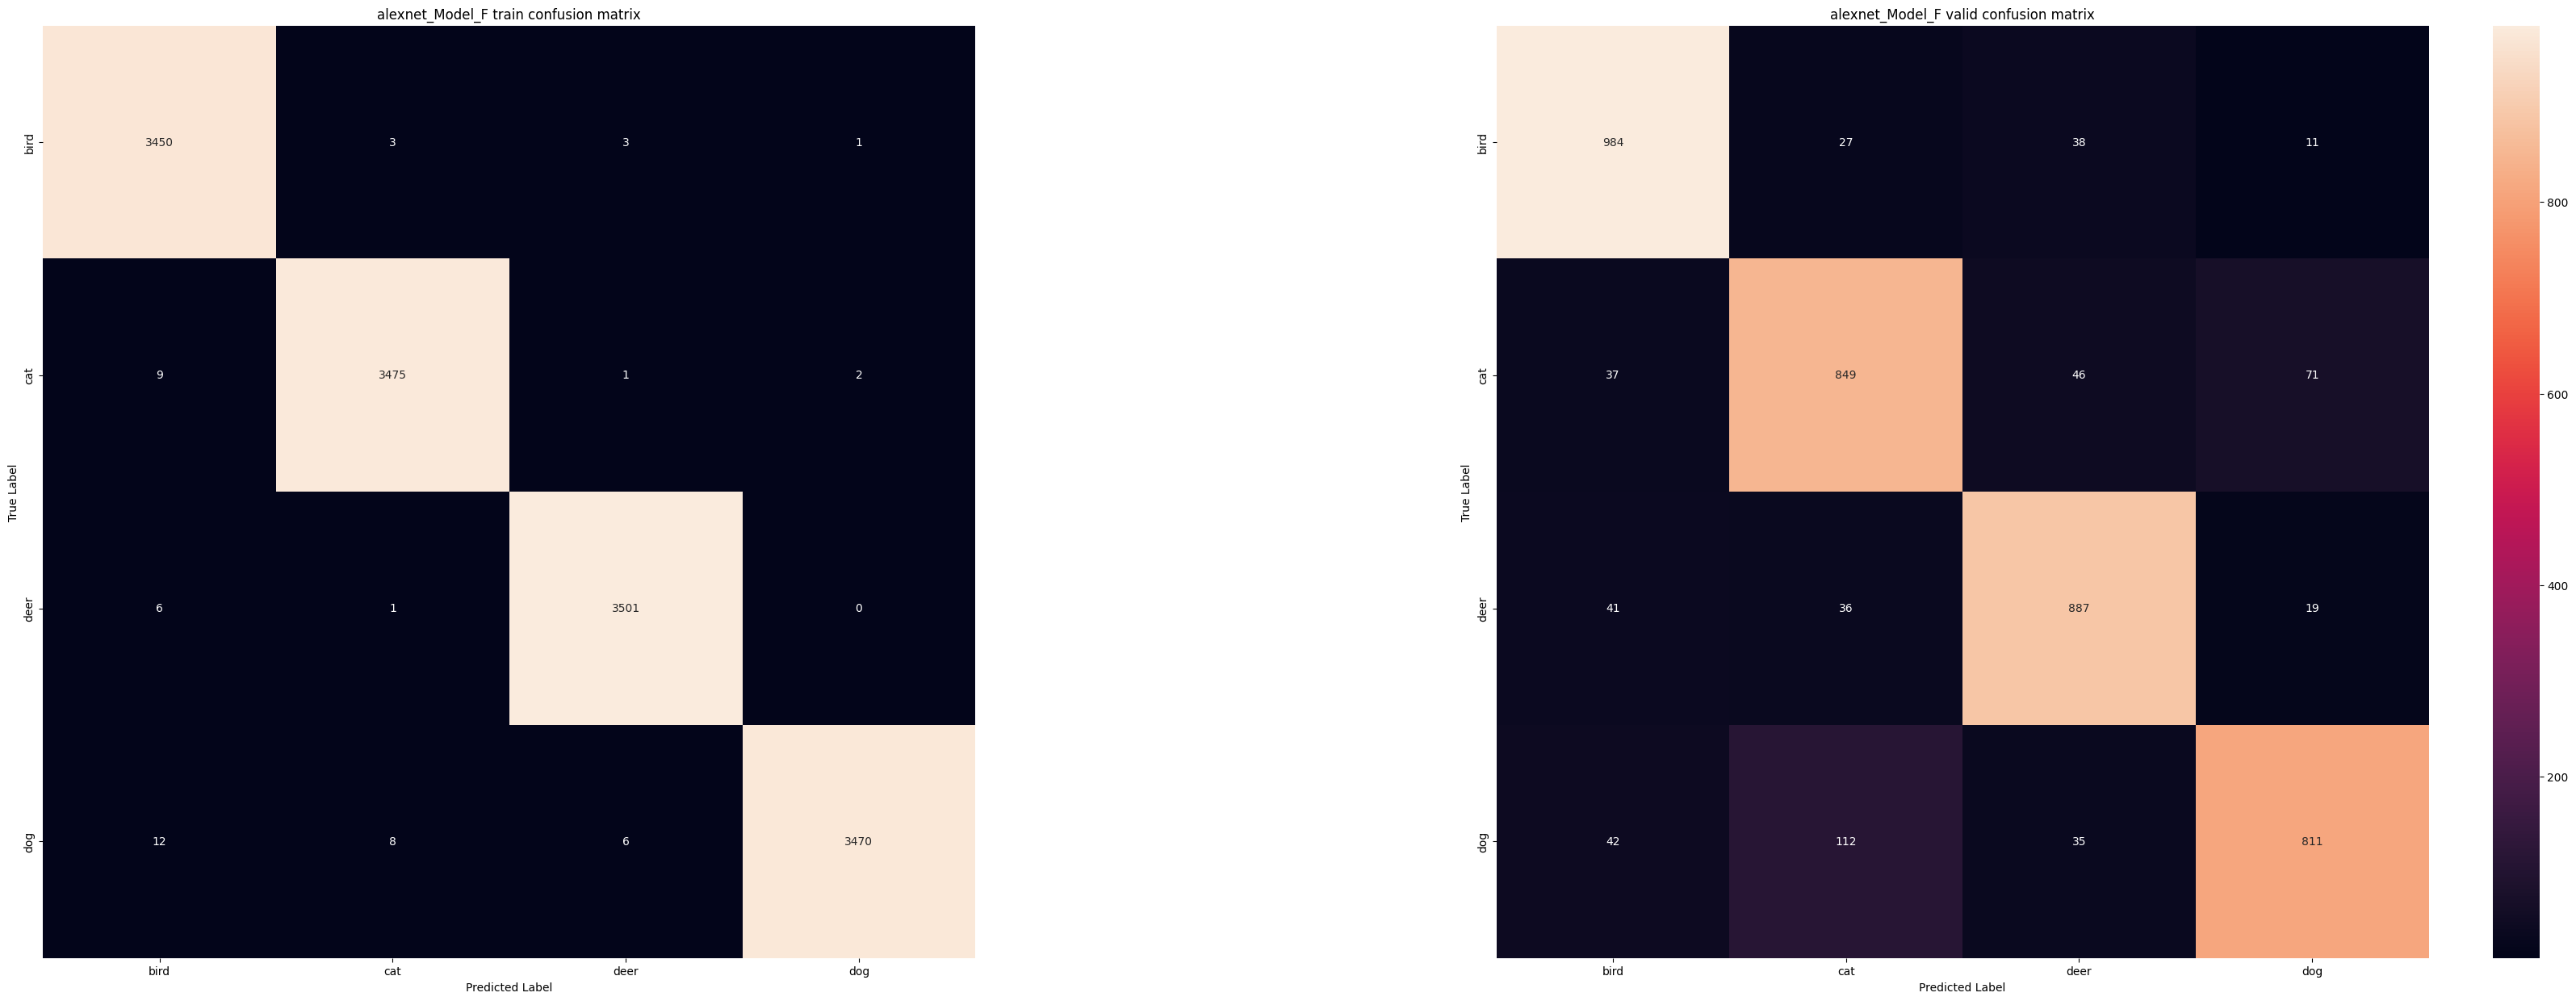

In [45]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [46]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [47]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,9551,6,3,6,6,0.996487,1.000000,0.989808,0.865911,False,True,True,True,True
1,16219,0,2,0,0,0.997086,0.999967,0.675708,0.999421,False,True,True,True,True
2,49054,3,3,7,5,0.999764,0.838217,0.492468,1.000000,True,False,False,False,False
3,8670,9,3,9,9,0.470069,0.999182,0.902154,0.999463,False,True,True,True,True
4,697,5,5,7,9,0.994508,0.618077,0.326430,0.999922,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,28632,5,5,7,5,0.996679,0.982828,0.862201,0.999998,True,False,True,False,False
34996,31784,6,4,6,6,0.958486,1.000000,0.840649,0.914342,False,True,True,True,True
34997,432,1,3,1,1,0.972328,1.000000,0.999737,1.000000,False,True,True,True,True
34998,19744,7,3,7,7,0.843716,1.000000,0.991536,1.000000,False,True,True,True,True


In [48]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

17

In [49]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

118

In [50]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
540,8538,6,4,6,6,0.944541,0.981888,0.457679,0.813145,False,True,True,False,True
880,8293,6,4,6,6,0.581062,0.999993,0.776792,0.550877,False,True,True,False,True
948,30759,6,3,6,3,0.990243,0.999993,0.786714,0.882117,False,True,False,False,True
1114,25539,7,2,7,7,0.499364,0.979273,0.473480,0.513218,False,True,True,False,True
1330,45080,6,3,6,3,0.949200,0.999694,0.426762,0.530500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34461,41676,8,4,8,8,0.999954,0.996781,0.874004,0.761720,False,True,True,False,True
34631,33256,6,2,6,4,0.982579,0.999999,0.558461,0.675177,False,True,False,False,True
34744,13915,0,4,0,7,0.999679,0.999996,0.486610,0.587028,False,True,False,False,True
34841,2517,6,2,6,6,0.949848,1.000000,0.975288,0.637245,False,True,True,False,True


In [51]:
df_results[(df_results['Decision']!=df_results['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
540,8538,6,4,6,6,0.944541,0.981888,0.457679,0.813145,False,True,True,False,True
880,8293,6,4,6,6,0.581062,0.999993,0.776792,0.550877,False,True,True,False,True
948,30759,6,3,6,3,0.990243,0.999993,0.786714,0.882117,False,True,False,False,True
1114,25539,7,2,7,7,0.499364,0.979273,0.473480,0.513218,False,True,True,False,True
1330,45080,6,3,6,3,0.949200,0.999694,0.426762,0.530500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34461,41676,8,4,8,8,0.999954,0.996781,0.874004,0.761720,False,True,True,False,True
34631,33256,6,2,6,4,0.982579,0.999999,0.558461,0.675177,False,True,False,False,True
34744,13915,0,4,0,7,0.999679,0.999996,0.486610,0.587028,False,True,False,False,True
34841,2517,6,2,6,6,0.949848,1.000000,0.975288,0.637245,False,True,True,False,True


In [52]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,36857,5,2,7,5,0.850874,0.998084,0.498287,0.999946,False,False,True,False,False
1,18497,3,3,7,3,0.997986,0.974646,0.414271,0.996570,True,False,True,False,False
2,41868,0,2,0,0,0.999915,1.000000,0.587135,0.999483,False,True,True,True,True
3,43814,0,2,0,0,0.999946,0.999819,0.823397,1.000000,False,True,True,True,True
4,19765,1,3,1,1,0.801861,0.999755,0.904207,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,27369,9,3,9,9,0.691050,1.000000,0.978143,1.000000,False,True,True,True,True
9996,43429,8,3,8,8,0.811927,1.000000,0.985613,0.997075,False,True,True,True,True
9997,37055,7,5,7,7,0.640802,0.969549,0.508834,0.708578,False,True,True,False,True
9998,11840,7,4,7,7,0.999999,0.999999,0.957127,0.999757,False,True,True,True,True


In [53]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

60

In [54]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

133

In [55]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
102,11348,2,2,6,6,0.995732,0.999949,0.882527,0.575622,True,False,False,True,False
194,35122,7,4,7,7,0.803869,1.000000,0.609223,0.528576,False,True,True,False,True
219,30674,4,4,7,4,0.806248,0.997281,0.438042,0.596753,True,False,True,True,False
274,20993,6,4,6,6,0.995125,0.858433,0.202350,0.685655,False,True,True,False,True
292,41715,3,3,8,8,0.940204,0.857831,0.548212,0.836239,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9830,26066,6,3,6,3,0.999994,1.000000,0.825341,0.631414,False,True,False,False,True
9843,36561,6,4,6,4,0.593443,0.999806,0.552055,0.720459,False,True,False,False,True
9868,22521,0,3,0,2,0.497606,0.585841,0.406544,0.534298,False,True,False,False,True
9903,11650,2,2,0,0,0.999080,0.999997,0.845681,0.856108,True,False,False,True,False


In [56]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(softmax_decision<0.9):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [57]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.1391421123725495, 0.9923428571428572, 13973, 21027)

In [58]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(1.5025025426119567, 0.8792, 4091, 5909)